<a href="https://colab.research.google.com/github/sakshamdh/Python-learning-journey-for-AI/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 - Data Preprocessing

In [50]:
!pip install tensorflow

In [83]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [84]:
## import some basic libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [85]:
dataset = pd.read_csv('Churn_Modelling.csv')

In [86]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [87]:
## Dividing the dataset into independant and depandant features

X = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]

In [88]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [89]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [90]:
# Feature Engineering

geography = pd.get_dummies(X['Geography'],drop_first=True)
gender = pd.get_dummies(X['Gender'],drop_first=True)

In [91]:
# concatenate these variables with dataframe

X = X.drop(['Geography','Gender'],axis=1) ##(axis=1 means column)

In [92]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [93]:
X = pd.concat([X,geography,gender],axis=1) ##(adding the categorical variables again)

In [94]:
# Splitting the dataset into Training set and Test set

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [95]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [96]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [97]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [98]:
X_train.shape

(8000, 11)

# Part 2 - ANN

In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, ReLU, LeakyReLU, ELU, PReLU, Dropout

In [100]:
# Lets initialize the ANN

classifier = Sequential()

In [101]:
# Adding the input layer

classifier.add(Dense(units=11,activation='relu'))

In [102]:
# adding the first hidden layer

classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.2))

In [103]:
# adding the second hidden layer

classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.3))

In [104]:
# adding the output layer

classifier.add(Dense(1,activation='sigmoid'))

In [105]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Early Stopping

In [106]:
import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [107]:
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7731 - loss: 0.5458 - val_accuracy: 0.7955 - val_loss: 0.4659
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7968 - loss: 0.4786 - val_accuracy: 0.7967 - val_loss: 0.4408
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8020 - loss: 0.4568 - val_accuracy: 0.8092 - val_loss: 0.4235
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8061 - loss: 0.4403 - val_accuracy: 0.8213 - val_loss: 0.4146
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8149 - loss: 0.4276 - val_accuracy: 0.8236 - val_loss: 0.4060
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8182 - loss: 0.4250 - val_accuracy: 0.8247 - val_loss: 0.4004
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8237 - loss: 0.4090 - val_accuracy: 0.8243 - val_loss: 0.3915
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8214 - loss: 0.4041 - 

In [75]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

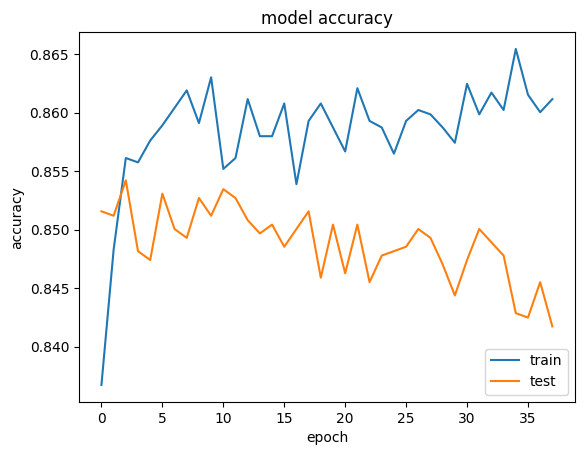

In [76]:
# summarize history for accuracy

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='lower right')
plt.show()

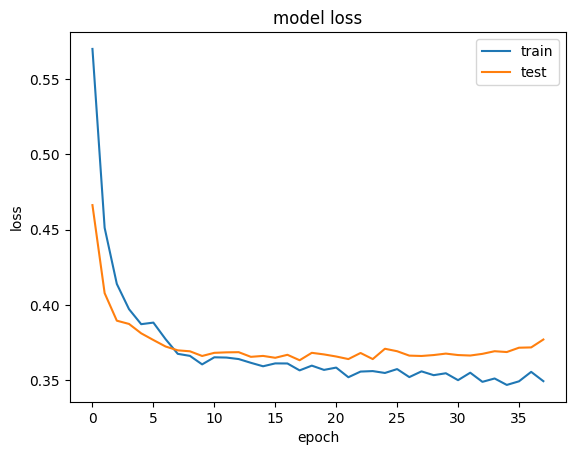

In [77]:
# summarize history for loss

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper right')
plt.show()

# Part 3 - Predictions and evaluating the model

In [78]:
# Predicting the Test set results

y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [79]:
# make the confusion matrix

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test,y_pred)
score = accuracy_score(y_test,y_pred)

In [80]:
cm

array([[  32, 1563],
       [  27,  378]])

In [81]:
score

0.205

In [82]:
# get the weights

classifier.get_weights()

[array([[ 0.34742063, -0.3424158 , -0.11579806,  0.28663546,  0.19470632,
          0.1877833 , -0.3621448 ,  0.39558083, -0.10973942, -0.12779075,
         -0.08989701],
        [ 0.25440377, -0.00921148, -0.39875883, -0.26305273, -0.0043084 ,
         -0.32555538, -0.3447438 , -0.50610006,  0.11457711, -0.43156886,
          0.23082519],
        [ 0.04306364,  0.49257427,  0.4535272 , -0.48532817, -0.20655319,
          0.29654205, -0.12085965, -0.13893366, -0.28141236,  0.00824046,
         -0.25138402],
        [ 0.23040086,  0.45757753,  0.3586493 ,  0.39895296,  0.03318352,
         -0.50456345, -0.28205234,  0.25093317, -0.42067486,  0.31646532,
          0.11216223],
        [ 0.27078718, -0.52057844, -0.23102975, -0.44665647,  0.05969197,
          0.24604303,  0.20637977, -0.31847924,  0.27717477, -0.3035673 ,
         -0.15087181],
        [-0.07357648, -0.37066948, -0.09673807, -0.3074864 ,  0.32221788,
          0.07160544, -0.2501445 ,  0.3310315 , -0.26359335, -0.3461905